In [1]:
import os
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')


In [2]:
import os
print("LD_LIBRARY_PATH:", os.environ.get('LD_LIBRARY_PATH'))


LD_LIBRARY_PATH: /usr/local/cuda/lib64:


In [3]:
import tensorflow as tf
print("GPUs detected:", tf.config.list_physical_devices('GPU'))


2025-06-19 23:14:49.761184: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-19 23:14:49.778153: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750392889.791403   49205 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750392889.795841   49205 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750392889.810252   49205 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import os
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow import keras
from tensorflow.keras import layers, models #type: ignore
from tensorflow.keras.applications import ResNet50  #type: ignore
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator #type: ignore
from tensorflow.keras.utils import to_categorical #type: ignore
from tensorflow.keras.optimizers import Adam #type: ignore
from tensorflow.keras.optimizers.schedules import ExponentialDecay #type: ignore
from tensorflow.keras.regularizers import l2 #type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau #type: ignore
from tensorflow.keras.metrics import AUC, Precision, Recall #type: ignore

In [5]:
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array

class ImageDataset:
    def __init__(self, data_dir, max_images_per_class=1400):
        self.data_dir = data_dir
        self.max_images_per_class = max_images_per_class
        self.images = []
        self.labels = []
        self.class_names = ['liriomyza', 'rust', 'bacterial_spot']
        
    def load_data(self):
        """Carga datos con validación mejorada y límite de imágenes"""
        total_images = 0
        class_counts = {}
        
        for idx, label in enumerate(self.class_names):
            label_dir = os.path.join(self.data_dir, label)
            if not os.path.exists(label_dir):
                print(f"Advertencia: no existe la carpeta {label_dir}")
                continue
                
            class_count = 0
            for image_name in os.listdir(label_dir):
                if not image_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                    continue
                    
                img_path = os.path.join(label_dir, image_name)
                img_array = self.load_and_preprocess_image(img_path)
                if img_array is not None:
                    self.images.append(img_array)
                    self.labels.append(idx)
                    class_count += 1
                    total_images += 1
                if class_count >= self.max_images_per_class:
                    print(f"Clase '{label}': Se han cargado el máximo de {self.max_images_per_class} imágenes.")
                    break
            
            class_counts[label] = class_count
            print(f"Clase '{label}': {class_count} imágenes")
        
        print(f"Total de imágenes cargadas: {total_images}")
        
        if class_counts:
            max_count = max(class_counts.values())
            min_count = min(class_counts.values())
            ratio = max_count / min_count if min_count > 0 else float('inf')
            
            if ratio > 3:
                print(f"Desbalance detectado: ratio {ratio:.2f}:1")
                print("Considera usar class_weight o data augmentation")
        
        return class_counts

    def load_and_preprocess_image(self, img_path):
        """Carga y preprocesa imagen con manejo de errores mejorado"""
        try:
            img = load_img(img_path, target_size=(224, 224))
            img_array = img_to_array(img) / 255.0
            return img_array
        except Exception as e:
            print(f"Error al cargar {img_path}: {e}")
            return None


In [6]:
print("Clasificador de Plagas")
print("=" * 50)

data_dir = 'data_3/'
dataset = ImageDataset(data_dir)
class_counts = dataset.load_data()

if not dataset.images:
    print("No se cargaron imágenes.")
    exit(1)

Clasificador de Plagas
Clase 'liriomyza': Se han cargado el máximo de 1400 imágenes.
Clase 'liriomyza': 1400 imágenes
Clase 'rust': Se han cargado el máximo de 1400 imágenes.
Clase 'rust': 1400 imágenes
Clase 'bacterial_spot': Se han cargado el máximo de 1400 imágenes.
Clase 'bacterial_spot': 1400 imágenes
Total de imágenes cargadas: 4200


In [7]:
images = np.array(dataset.images)
labels = np.array(dataset.labels)
labels_cat = to_categorical(labels, num_classes=3)

print(f"\nDatos preparados:")
print(f"Imágenes: {images.shape}")
print(f"Etiquetas: {labels_cat.shape}")


Datos preparados:
Imágenes: (4200, 224, 224, 3)
Etiquetas: (4200, 3)


In [8]:
X_train, X_val, y_train, y_val = train_test_split(
        images, labels_cat, 
        test_size=0.2, 
        random_state=42, 
        stratify=labels
    )

print(f"\nDivisión de datos:")
print(f"Entrenamiento: {X_train.shape[0]} imágenes")
print(f"Validación: {X_val.shape[0]} imágenes")


División de datos:
Entrenamiento: 3360 imágenes
Validación: 840 imágenes


In [9]:
# Importaciones necesarias
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization,
    Multiply, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, TensorBoard
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import (
    Precision, Recall, AUC, F1Score
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from keras import Model

In [10]:
data_augmentation = tf.keras.Sequential(
  [
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
  ]
)

I0000 00:00:1750392918.371997   49205 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5578 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [ ]:
from tensorflow.keras import regularizers

base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0001))(x) 
prediction_layer = tf.keras.layers.Dense(3, activation='softmax')(x)

modelo = tf.keras.Model(inputs=inputs, outputs=prediction_layer)


    
modelo.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            Precision(),
            Recall(),
            AUC(),
        ]
    )


In [12]:
def configurar_callbacks():
    """
    Configura los callbacks para el entrenamiento.
    """
    callbacks = [
        EarlyStopping(
            patience=3,
            min_delta=0.001,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6
        )
    ]
    
    return callbacks

callbacks = configurar_callbacks()

In [13]:
def entrenar_modelo(modelo, X_train, y_train, X_val, y_val, callbacks, epochs, batch_size):
    """
    Entrena el modelo con los generadores y callbacks configurados.
    """
    history = modelo.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        callbacks=callbacks,
        batch_size=batch_size,
        verbose=1
    )
    
    return history


In [14]:
history = entrenar_modelo(modelo, X_train, y_train, X_val, y_val, callbacks, epochs=30, batch_size=32)

Epoch 1/30


I0000 00:00:1750392927.094929   49323 cuda_dnn.cc:529] Loaded cuDNN version 91001


105/105 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - accuracy: 0.3520 - auc: 0.5113 - loss: 1.3177 - precision: 0.3541 - recall: 0.1850 - val_accuracy: 0.3536 - val_auc: 0.6450 - val_loss: 1.1035 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.3472 - auc: 0.5174 - loss: 1.1453 - precision: 0.3531 - recall: 0.0462 - val_accuracy: 0.3833 - val_auc: 0.6651 - val_loss: 1.0755 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.3887 - auc: 0.5430 - loss: 1.1291 - precision: 0.3851 - recall: 0.0581 - val_accuracy: 0.3738 - val_auc: 0.5974 - val_loss: 1.0922 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.3795 - auc: 0.5574 - loss: 1.1111 - precision: 0.5134 - recall: 0.0418 - val_accuracy: 0.4893 - val_auc: 0.6278 - val_

In [15]:
def evaluar_modelo(modelo, X_val, y_val):
    """
    Evalúa el modelo con métricas detalladas.
    """
    y_pred = modelo.predict(X_val)
    y_pred_class = np.argmax(y_pred, axis=1)
    y_true_class = np.argmax(y_val, axis=1)

    metrics = {}
    for i in range(3):
        y_pred_i = (y_pred_class == i)
        y_true_i = (y_true_class == i)
        
        metrics[f'clase_{i}'] = {
            'precision': precision_score(y_true_i, y_pred_i),
            'recall': recall_score(y_true_i, y_pred_i),
            'f1': f1_score(y_true_i, y_pred_i),
            'auc': roc_auc_score(y_true_i, y_pred_i)
        }

    metrics['general'] = {
        'accuracy': accuracy_score(y_true_class, y_pred_class),
        'macro_f1': f1_score(y_true_class, y_pred_class, average='macro'),
        'macro_precision': precision_score(y_true_class, y_pred_class, average='macro'),
        'macro_recall': recall_score(y_true_class, y_pred_class, average='macro')
    }
    
    return metrics

metrics = evaluar_modelo(modelo, X_val, y_val)
print(metrics)

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
{'clase_0': {'precision': 0.4636363636363636, 'recall': 0.9107142857142857, 'f1': 0.6144578313253012, 'auc': np.float64(0.6919642857142857)}, 'clase_1': {'precision': 0.6068965517241379, 'recall': 0.6285714285714286, 'f1': 0.6175438596491228, 'auc': np.float64(0.7125000000000001)}, 'clase_2': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'auc': np.float64(0.5)}, 'general': {'accuracy': 0.513095238095238, 'macro_f1': 0.410667230324808, 'macro_precision': 0.35684430512016724, 'macro_recall': 0.513095238095238}}


/home/juan0/Backend-Tesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juan0/Backend-Tesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


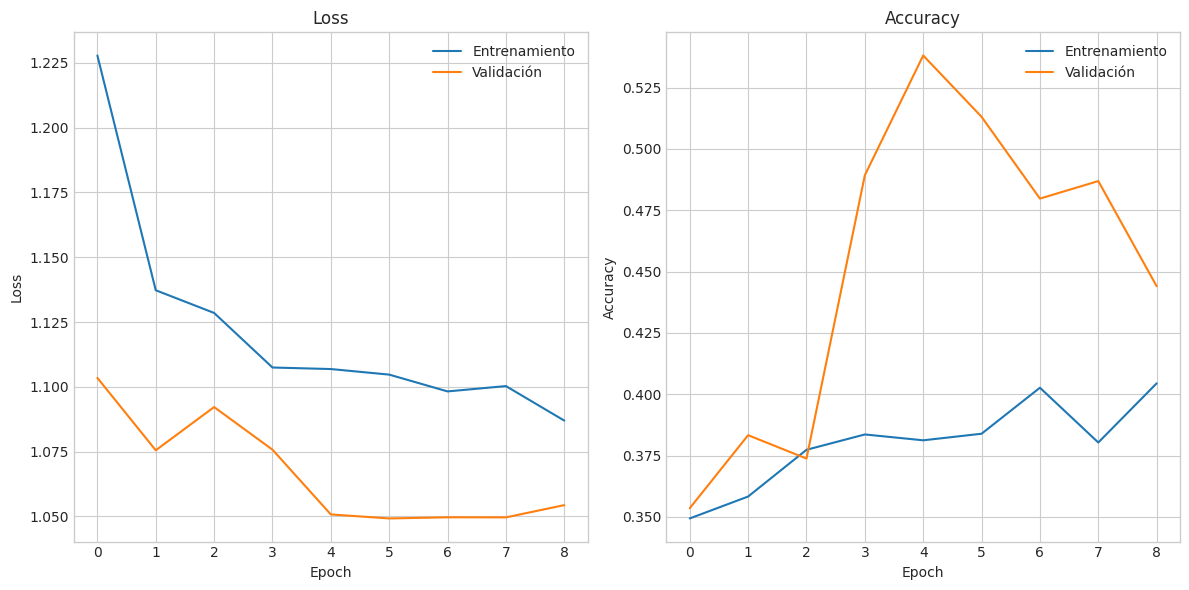

In [16]:

def visualizar_resultados(history):
    """
    Visualiza las métricas de entrenamiento.
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['figure.figsize'] = [12, 6]
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

visualizar_resultados(history)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


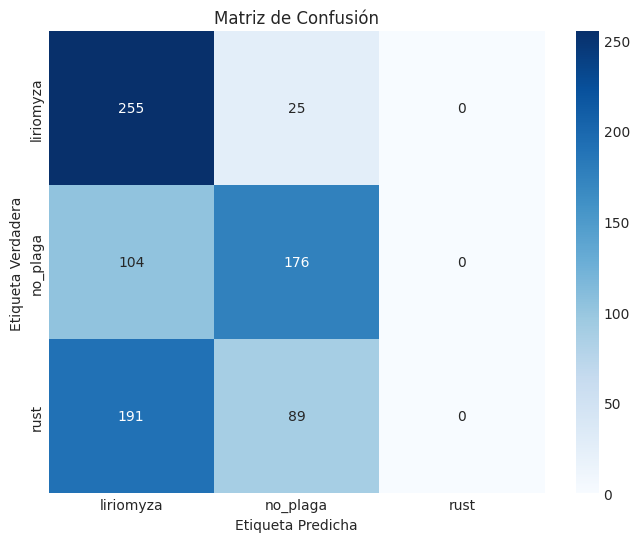

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_probs = modelo.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)
cm = confusion_matrix(y_true, y_pred)
class_names = ['liriomyza', 'no_plaga', 'rust']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


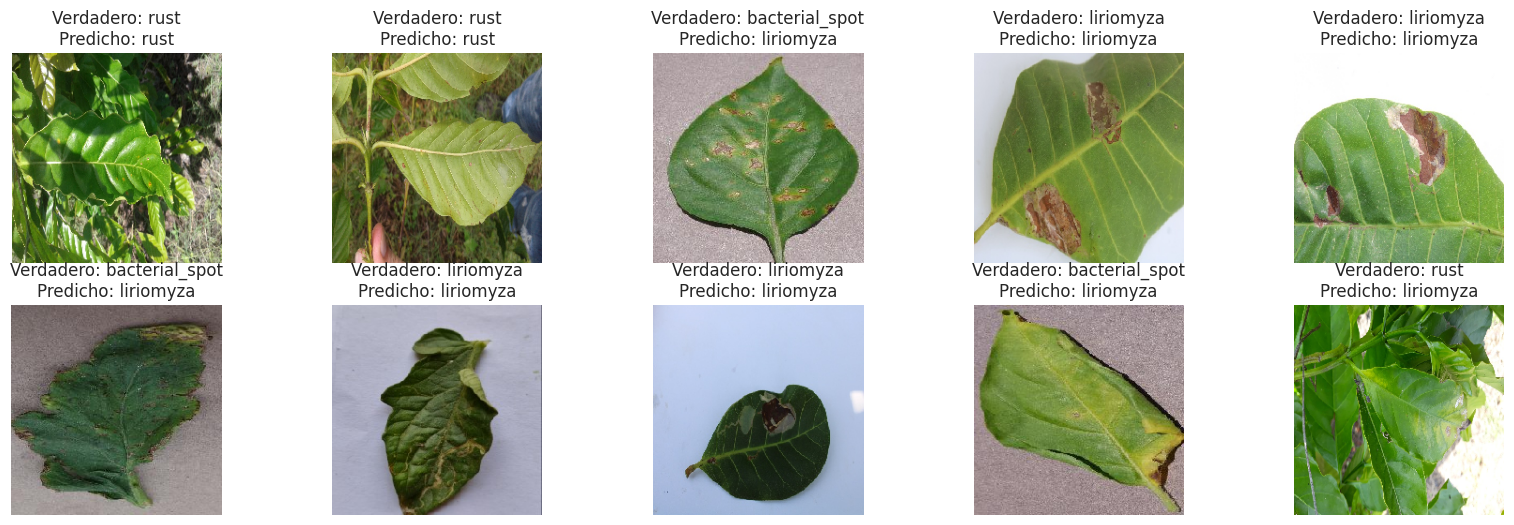

In [18]:
import random
import matplotlib.pyplot as plt
import numpy as np

indices = random.sample(range(len(X_val)), 10)
class_names = ['liriomyza', 'rust', 'bacterial_spot']

plt.figure(figsize=(20, 6))

for i, idx in enumerate(indices):
    img = X_val[idx]
    true_label = np.argmax(y_val[idx])
    
    img_input = np.expand_dims(img, axis=0)
    pred_probs = modelo.predict(img_input)
    pred_label = np.argmax(pred_probs[0])
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Verdadero: {class_names[true_label]}\nPredicho: {class_names[pred_label]}")
    
plt.show()




In [19]:
base_model.trainable = True

print(f"Número de capas en el modelo base: {len(base_model.layers)}")

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

print(f"Capas de la 1 a la {fine_tune_at} congeladas.")
print(f"{len(base_model.layers)-fine_tune_at} capas descongeladas")

modelo.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
              metrics=['accuracy'])




Número de capas en el modelo base: 154
Capas de la 1 a la 100 congeladas.
54 capas descongeladas


In [20]:
initial_epochs = 30
fine_tune_epochs = 20
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = modelo.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=total_epochs, initial_epoch=history.epoch[-1], callbacks=callbacks,)

Epoch 9/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - accuracy: 0.3511 - loss: 1.2006 - val_accuracy: 0.3488 - val_loss: 1.0984 - learning_rate: 1.0000e-06
Epoch 10/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.4266 - loss: 1.0815 - val_accuracy: 0.3333 - val_loss: 1.1376 - learning_rate: 1.0000e-06
Epoch 11/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.4570 - loss: 1.0357 - val_accuracy: 0.3333 - val_loss: 1.1884 - learning_rate: 1.0000e-06
Epoch 12/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.4769 - loss: 1.0031 - val_accuracy: 0.3333 - val_loss: 1.2512 - learning_rate: 1.0000e-06


In [21]:
modelo.save("modelo_plagas_multiclasev3.h5")